# Implémentation de l’algorithme Gibbs-ABC

## Introduction

Dans ce notebook, nous implémentons l'algorithme Gibbs-ABC proposé dans l’article *"Component-wise approximate Bayesian computation via Gibbs-like steps"*.

L’objectif est d’estimer les paramètres d’un modèle de séries temporelles de type Moving Average d’ordre 2 (MA(2)) à l’aide de méthodes d’inférence bayésienne approchée.

---

## Modèle MA(2)

On considère le modèle suivant :

$$
X_t = Z_t + \theta_1 Z_{t-1} + \theta_2 Z_{t-2}
$$

où :
- $(Z_t)$ est un bruit blanc gaussien tel que $Z_t \sim \mathcal{N}(0,1)$
- $\theta = (\theta_1, \theta_2)$ est le vecteur de paramètres à estimer

À partir de valeurs vraies $\theta_{\text{true}}$, nous simulons une série observée $x_{\text{obs}}$.

Le MA(2) est intéressant car il est simple à simuler, il reste non trivial, il introduit une dépendance temporelle de court terme, ce qui le rend pertinent pour l’étude de séries temporelles et enfin sa vraisemblance est difficile à manipuler analytiquement ce qui justifie l’usage de méthodes approchées comme l’ABC.
Ainsi, le modèle MA(2) est particulièrement adapté pour comparer et analyser les performances des algorithmes d’inférence bayésienne approchée.

---

## Approximate Bayesian Computation (ABC)

Dans ce modèle, la vraisemblance est difficile à exploiter directement.  
Les méthodes ABC permettent de contourner ce problème en procédant comme suit :

1. Simuler des données $x_{\text{sim}}$ à partir d’un paramètre $\theta$
2. Comparer des statistiques résumées $s(x_{\text{sim}})$ et $s(x_{\text{obs}})$
3. Accepter $\theta$ si la distance est suffisamment petite

Formellement, on accepte $\theta$ si :

$$
d\big(s(x_{\text{sim}}), s(x_{\text{obs}})\big) < \epsilon
$$

où $\epsilon > 0$ est un seuil de tolérance.

---

## Algorithme Gibbs-ABC

L’algorithme Gibbs-ABC améliore l’ABC standard en mettant à jour les paramètres un par un, de manière similaire à un échantillonneur de Gibbs.

À chaque itération, on effectue :

$$
\theta_1^{(t+1)} \sim \text{ABC}(\theta_1 \mid \theta_2^{(t)}, x_{\text{obs}})
$$

$$
\theta_2^{(t+1)} \sim \text{ABC}(\theta_2 \mid \theta_1^{(t+1)}, x_{\text{obs}})
$$

À chaque itération, les paramètres sont mis à jour un par un.
On commence par mettre à jour $\theta_1$ en gardant $\theta_2$ fixé, puis on met à jour $\theta_2$ en utilisant la nouvelle valeur de $\theta_1$.
Chaque mise à jour repose sur un critère ABC : on simule des données et on accepte la proposition si les statistiques simulées sont suffisamment proches des statistiques observées.

Cette approche permet de réduire le problème à 1 dimension seulement plutôt que de proposer tout $\theta$. On améliore ainsi l’efficacité de l’algorithme.

In [42]:
import numpy as np
import matplotlib.pyplot as plt

## Simuler un MA(2) 

In [43]:
def simulate_MA2(theta, n):
    theta1, theta2 = theta
    z = np.random.randn(n + 2)
    x = np.zeros(n)

    for t in range(2, n + 2):
        x[t - 2] = z[t] + theta1 * z[t-1] + theta2 * z[t-2]

    return x

Commentaires : On simule une fonction qui génère une série temporelle. On récupère ensuite nos deux paramètres theta1 et theta2. On génère Z qui suit une loi normale centrée réduite. (n + 2) car MA(2) dépend de t-1 et de t-2. X est la série observée initialisée. Puis on simule la boucle temporelle, en commençant à 2 pour pouvoir utiliser t-1 et t-2. On trouve bien la relation suivante : $$
X_t = Z_t + \theta_1 Z_{t-1} + \theta_2 Z_{t-2}
$$ On renvoie in fine la série simulée. 

## Statistiques résumées par ACF

In [44]:
def acf_stats(x, max_lag=5):
    x = x - np.mean(x)
    n = len(x)

    acf_vals = []
    for k in range(1, max_lag + 1):
        acf_vals.append(np.sum(x[k:] * x[:-k]) / n)

    return np.array(acf_vals)

Commentaires : Dans le cadre de l’ABC, nous ne comparons pas directement les données simulées et observées, mais des statistiques résumées qui capturent l’information essentielle. Dans le cas d’un modèle MA(2), cette information est contenue dans la dépendance temporelle entre les observations.

Pour une série temporelle $(X_t)$, l’autocovariance au lag $k$ est définie par :

$$
\gamma(k) = \mathbb{E}[X_t X_{t-k}]
$$

En pratique, on ne connaît pas l’espérance, on utilise donc une version empirique :

$$
\hat{\gamma}(k) = \frac{1}{n} \sum_{t=k+1}^{n} x_t \, x_{t-k}
$$

- Si $\gamma(k)$ est grand → les valeurs séparées de $k$ périodes sont corrélées  
- Si $\gamma(k) \approx 0$ → pas de dépendance à ce lag  

Ainsi, l’autocovariance mesure la dépendance temporelle de la série.

Dans le code ci-dessus, la fonction acf_stats calcule les autocovariances empiriques de la série.

## Calculer la distance

In [45]:
def distance(s_sim, s_obs):
    return np.sum((s_sim - s_obs)**2)

Commentaires : La fonction distance calcule alors la différence entre ces statistiques résumées :

$$
d(s(x_{sim}), s(x_{obs})) = \sum (s(x_{sim}) - s(x_{obs}))^2
$$

Si cette distance est inférieure à un seuil $\epsilon$, le paramètre proposé est accepté.

## Gibbs-ABC

In [46]:
def gibbs_abc(x_obs, n_iter=10000, epsilon=0.1, sigma=0.1):

    s_obs = acf_stats(x_obs)
    theta = np.array([0.0, 0.0])

    chain = np.zeros((n_iter, 2))

    for t in range(n_iter):

        theta_prop = theta.copy()
        theta_prop[0] = theta_prop[0] + np.random.normal(0, sigma)

        x_sim = simulate_MA2(theta_prop, len(x_obs))
        if distance(acf_stats(x_sim), s_obs) < epsilon:
            theta[0] = theta_prop[0]

        theta_prop = theta.copy()
        theta_prop[1] = theta_prop[1] + np.random.normal(0, sigma)

        x_sim = simulate_MA2(theta_prop, len(x_obs))
        if distance(acf_stats(x_sim), s_obs) < epsilon:
            theta[1] = theta_prop[1]

        chain[t] = theta

    return chain

Commentaires : 
x_obs sont les données observées, on itère 5000 fois, epsilon est le seuil ABC (fonction distance). 
s_obs sont les stats des données observées (notre référence). 
On a ensuite la boucle for pour la chaîne de Markov. 
On propose un nouveau $\theta_1$ tandis que $\theta_2$ reste fixe. 
On simule des données avec ce nouveau paramètre. 
On fait le test ABC : si les stats sont proches (la distance est inférieure à epsilon) alors on accepte le paramètre. 
On fait de même avec $\theta_2$ en gardant $\theta_1$ fixe. 

## Test 

In [47]:
theta_true = [0.6, 0.2]
n = 200

x_obs = simulate_MA2(theta_true, n)

chain = gibbs_abc(x_obs)

np.mean(chain, axis=0)

array([0.52332523, 0.10488521])

Commentaires : 
theta_true sont les vrais paramètres. Ensuite on simule nos données observées à partir de nos vrais paramètres. On trouve in fine l'estimation finale des paramètres. 

Les estimations obtenues sont proches des valeurs vraies, bien qu’un biais subsiste.
Cela s’explique par la nature approximative de l’ABC, le choix du seuil ε, ainsi que la variabilité Monte Carlo liée au nombre fini d’itérations.
Malgré cela, l’algorithme capture correctement l’ordre de grandeur des paramètres.

## Plot : représentation graphique

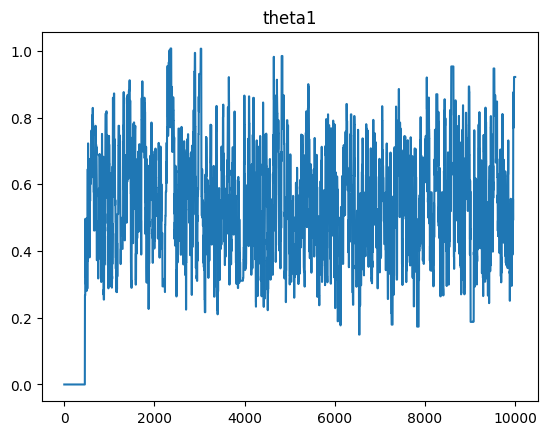

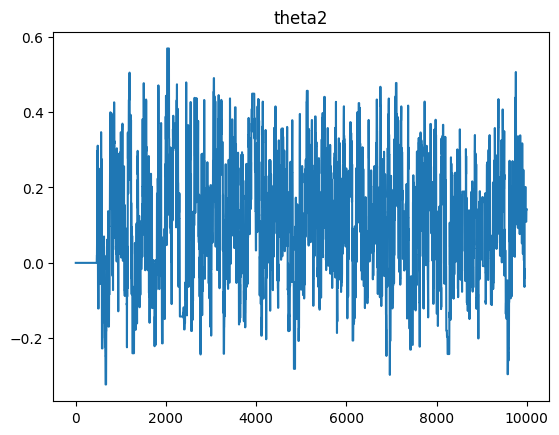

In [48]:
plt.plot(chain[:,0])
plt.title("theta1")
plt.show()

plt.plot(chain[:,1])
plt.title("theta2")
plt.show()

Commentaires :

Les graphiques représentent l’évolution des paramètres $\theta_1$ et $\theta_2$ au cours des itérations de l’algorithme Gibbs-ABC.
Chaque point correspond à une valeur du paramètre à une itération donnée.

On observe que les valeurs fluctuent d'une itération à l'autre, il n'y a pas de convergence vers une valeur fixe et la chaîne explore bien différentes valeurs possibles pour nos paramètres. La chaîne de Markov explore bien une distribution. 

### Cas de $\theta_1$

Les valeurs de $\theta_1$ varient approximativement entre 0.2 et 1, avec des fluctuations importantes.
Cependant, on observe que la chaîne oscille majoritairement autour de 0.6, qui correspond à la vraie valeur du paramètre.
Cela indique que l’algorithme identifie correctement la zone de forte probabilité pour $\theta_1$.

### Cas de $\theta_2$

Les valeurs de $\theta_2$ varient entre environ -0.2 et 0.6.
De même malgré les fluctuations la chaîne se concentre autour de 0.2, qui est la vraie valeur du paramètre.


Pour conclure, les plots montrent que la chaîne explore correctement l'espace des paramètres, les valeurs se concentrent autour des paramètres vrais et que notre algorithme Gibbs-ABC permet une estimation cohérente des vrais paramètres. Cela valide le bon fonctionnement de l'algorithme. 